# Computing SSHA wavenumber spectra from Basic SWOT files

Files: LR_L2_BASIC (January 2026)

In [19]:
import numpy as np
import xarray as xr
import scipy.signal as signal
from scipy.ndimage import binary_dilation

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cmx



In [2]:
data_dir = '/Users/zoecas/Documents/data/SWOT_L2_LR_SSH_BASIC_D_D-20260603_062409/'
filename = 'SWOT_L2_LR_SSH_Basic_044_098_20260106T210232_20260106T215400_PID0_01.nc'

In [3]:
ds = xr.open_dataset(data_dir+filename)
ds

<xarray.Dataset> Size: 112MB
Dimensions:                                (num_lines: 9866, num_pixels: 69,
                                            num_sides: 2)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 5MB ...
    longitude                              (num_lines, num_pixels) float64 5MB ...
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/24)
    time                                   (num_lines) datetime64[ns] 79kB ...
    time_tai                               (num_lines) datetime64[ns] 79kB ...
    ssh_karin                              (num_lines, num_pixels) float64 5MB ...
    ssh_karin_qual                         (num_lines, num_pixels) float64 5MB ...
    ssh_karin_uncert                       (num_lines, num_pixels) float64 5MB ...
    ssha_karin                             (num_lines, num_pixels) float64 5MB ...
    ...                                     ...
    mean_sea_surface_cnescls               (num_lines, num_pixels) float64 5MB ...
    mean_sea_surface_cnescls_uncert        (num_lines, num_pixels) float64 5MB ...
    geoid                                  (num_lines, num_pixels) float64 5MB ...
    internal_tide_hret                     (num_lines, num_pixels) float64 5MB ...
    height_cor_xover                       (num_lines, num_pixels) float64 5MB ...
    height_cor_xover_qual                  (num_lines, num_pixels) float32 3MB ...
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   CNES
    source:                                        Ka-band radar interferometer
    history:                                       2026-01-08T16:17:27Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       67.80712455934498
    ssha_variance:                                 0.026332454950334927
    references:                                    V1.4.1
    equator_longitude:                             4.50

In [8]:
#parameters
SSH_VAR = "ssha_karin"
dx = 2000.0
min_seg = 200.0 #km
trend_scale = 200.0  #km
nperseg = 128 #km
edge_pixels = 10

In [9]:
ssh = ds[SSH_VAR] + ds['height_cor_xover'] # corrected ssha
ssh = ssh.where(ds['ssha_karin_qual']==0) # removing flagged data

lat = ds.latitude.where(ds['ssha_karin_qual']==0)# removing flagged data
lon = ds.longitude.where(ds['ssha_karin_qual']==0)# removing flagged data

In [10]:
# Dealing with land
land_candidates = [ "surface_classification_flag", "ancillary_surface_classification_flag", "land_flag" ] 
land = None
for v in land_candidates:
    if v in ds:
        land=ds[v]
        break
if land is not None:
    ocean = land == 0
    ocean = ocean & ~binary_dilation( ~ocean, iterations=5 )
    ssh = ssh.where(ocean)
    lat = lat.where(ocean)
    lon = lon.where(ocean)

In [11]:
#Removing edge pixels
lat = lat.isel( num_pixels=slice( edge_pixels, ssh.sizes["num_pixels"] - edge_pixels ) )
lon = lon.isel( num_pixels=slice( edge_pixels, ssh.sizes["num_pixels"] - edge_pixels ) )
ssh = ssh.isel( num_pixels=slice( edge_pixels, ssh.sizes["num_pixels"] - edge_pixels ) )


In [12]:
#Computing along track spectra

all_spectra = [] 
Lat,Lon = [], []
common_k = None 
for beam in range(ssh.sizes["num_pixels"]): 
    yfull = ssh.isel(num_pixels=beam).values
    lat_full = lat.isel(num_pixels=beam).values
    lon_full = lon.isel(num_pixels=beam).values
    valid = np.isfinite(yfull) # Dealing with breaks along tracks
    idx = np.where(valid)[0]
    if len(idx)<10:
        continue
    breaks = np.where(np.diff(idx)>1)[0]
    starts = np.r_[idx[0],idx[breaks+1]]
    ends = np.r_[idx[breaks],idx[-1]]
    for s,e in zip(starts,ends):
        length_km = (e - s + 1) * dx / 1000
        if length_km < min_seg:
            continue
        y = yfull[s:e+1]
        latitude = lat_full[s:e+1]
        longitude = lon_full[s:e+1]
        trend_pts = int( trend_scale * 1000 / dx )
        if trend_pts % 2 == 0:
            trend_pts += 1
        trend = signal.savgol_filter( y, trend_pts, polyorder=3 )
        y = y-trend
        nseg = int( nperseg * 1000 / dx )
        f, Pxx = signal.welch( y, fs=1 / dx, nperseg=nseg, noverlap=nseg // 2, window="hann", detrend=False, scaling="density" )
        if common_k is None: 
            common_k = f
        else: 
            Pxx = np.interp( common_k, f, Pxx )
        all_spectra.append(Pxx)
        Lat.append(np.mean(latitude))
        Lon.append(np.mean(longitude))

In [15]:
#Combining all segments
spectra = np.array(all_spectra)
mean_psd = np.nanmean( spectra, axis=0 )
p05 = np.nanpercentile( spectra, 5, axis=0 )
p95 = np.nanpercentile( spectra, 95, axis=0 )
k = common_k
mask = k > 0
k = k[mask]
mean_psd = mean_psd[mask]
p05 = p05[mask]
p95 = p95[mask]
wavelength = 1 / k / 1000 

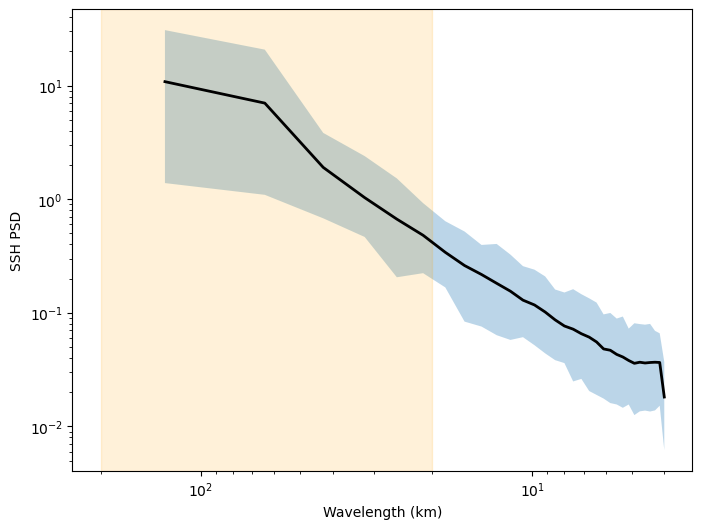

In [17]:
#Mean spectra
fig,ax = plt.subplots( figsize=(8,6) )
ax.loglog( wavelength, mean_psd, color="k", lw=2 )
ax.fill_between( wavelength, p05, p95, alpha=0.3 )
ax.axvspan( 20, 200, color="orange", alpha=0.15 )
ax.invert_xaxis() 
ax.set_xlabel("Wavelength (km)");ax.set_ylabel("SSH PSD")
plt.show()

In [21]:
power_ssh = xr.Dataset({'spectra':(['latitude','k'],spectra),
                        'latitude':(['latitude'],Lat),
                        'longitude':(['latitude'],Lon),'k':common_k})

In [22]:
power_ssh = power_ssh.sortby('latitude')

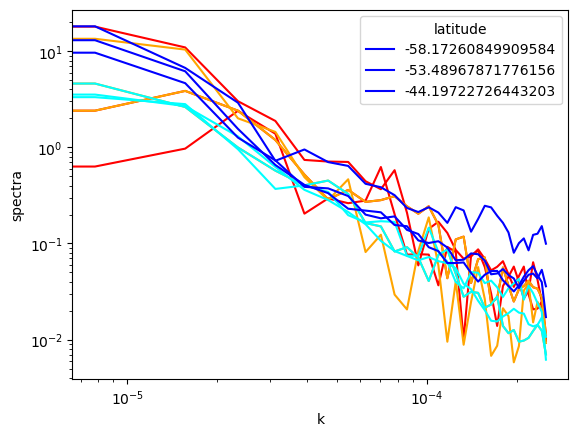

In [29]:
power_ssh.sel(latitude=[46,50,60],method='nearest').spectra.plot(hue='latitude',yscale='log',xscale='log',c='r')
power_ssh.sel(latitude=[0,20,30],method='nearest').spectra.plot(hue='latitude',yscale='log',xscale='log',c='orange')
power_ssh.sel(latitude=[-30,-20,0],method='nearest').spectra.plot(hue='latitude',yscale='log',xscale='log',c='cyan')
power_ssh.sel(latitude=[-60,-50,-44],method='nearest').spectra.plot(hue='latitude',yscale='log',xscale='log',c='b')
#,label=r'30$\deg$ N'
#plt.legend()

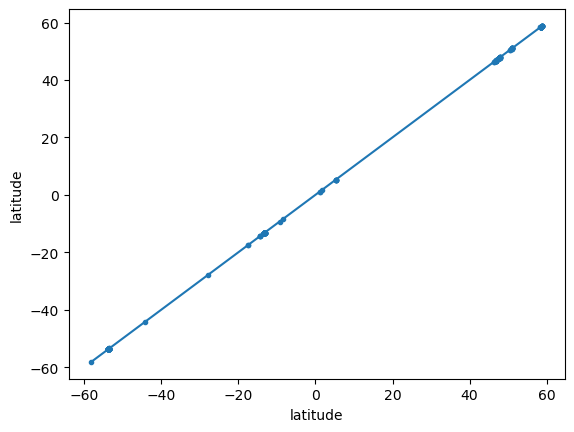

In [24]:
power_ssh.latitude.plot(marker='.'
                       )

In [28]:
power_ssh.sel(latitude=slice(-60,-30)).latitude

<xarray.DataArray 'latitude' (latitude: 42)> Size: 336B
array([-58.172608, -53.792805, -53.786832, -53.780852, -53.774865, -53.768871,
       -53.76287 , -53.756862, -53.750846, -53.744824, -53.738795, -53.732759,
       -53.726715, -53.720665, -53.714608, -53.708544, -53.702472, -53.696394,
       -53.690309, -53.684217, -53.678117, -53.614338, -53.60817 , -53.595815,
       -53.589627, -53.583432, -53.57723 , -53.571021, -53.564805, -53.558582,
       -53.552353, -53.546116, -53.539873, -53.533623, -53.527365, -53.521101,
       -53.514831, -53.508553, -53.502268, -53.495977, -53.489679, -44.197227])
Coordinates:
  * latitude  (latitude) float64 336B -58.17 -53.79 -53.79 ... -53.49 -44.2